# 06 — Final EDA Summary

Executive summary consolidating findings from all notebooks.

**Aggregates results from:** all analyzer classes  
**Outputs:** `final_eda_summary_report.md`, `summary.json`, `eda_summary_statistics.csv`

## Setup

In [1]:
import sys, time
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

NOTEBOOK_NAME = "06_final_eda_summary"
START_TIME = time.time()

from eda.utils.config import load_config
from eda.utils.logger import EDALogger
from eda.utils.metadata_loader import MetadataLoader
from eda.utils.wandb_manager import WandbManager
from eda.utils.plotting import PlotEngine, CATEGORICAL_COLOURS, DATASET_COLOURS, PALETTE
from eda.utils.report_generator import ReportGenerator
from eda.utils.system_monitor import SystemMonitor
from eda.utils.output_manager import OutputManager
from eda.utils.statistics import (
    OverviewAnalyzer, ClassAnalyzer, VideoAnalyzer,
    BBoxAnalyzer, SplitAnalyzer, QualityScorer,
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

config = load_config()
logger = EDALogger.setup(config, NOTEBOOK_NAME)
monitor = SystemMonitor()
plot_engine = PlotEngine(dpi=config.figure_dpi, formats=config.figure_formats)
output = OutputManager(config, NOTEBOOK_NAME)
snap_start = monitor.snapshot("start")
logger.log_start()

[22:15:12] INFO     ═══ EDA START: 06_final_eda_summary ═══ | EDA v1.0.0 | Python 3.13.2 | Windows


In [2]:
loader = MetadataLoader(config)
df = loader.load()
metadata_hash = loader.metadata_hash
git_commit = EDALogger.get_git_commit()

wb = WandbManager(config, NOTEBOOK_NAME)
wb.init(metadata_hash=metadata_hash, git_commit=git_commit)
wb.log_system_info(snap_start)
logger.log_data_loaded(df.shape[0], df.shape[1], metadata_hash)

Preprocessing: Completely empty columns: ['duplicate_group_id']


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Amita nagar\_netrc.


wandb: Currently logged in as: saksham4data (saksham4data-vinkura) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: Tracking run with wandb version 0.28.1


wandb: Run data is saved locally in E:\Rads\eda\notebooks\wandb\run-20260801_221517-us8n0ygz
wandb: Run `wandb offline` to turn off syncing.


wandb: Syncing run eda-06_final_eda_summary


wandb:  View project at https://wandb.ai/saksham4data-vinkura/RADS


wandb:  View run at https://wandb.ai/saksham4data-vinkura/RADS/runs/us8n0ygz


[22:15:18] INFO     Data loaded: 5338 rows × 51 columns | hash=sha256:a761cf722...


## Run All Analyzers

In [3]:
# Instantiate and run all analyzers
overview = OverviewAnalyzer(df, config)
overview_results = overview.analyze()

class_an = ClassAnalyzer(df, config)
class_results = class_an.analyze()

video_an = VideoAnalyzer(df, config)
video_results = video_an.analyze()

bbox_an = BBoxAnalyzer(df, config)
bbox_results = bbox_an.analyze()

split_an = SplitAnalyzer(df, config)
split_results = split_an.analyze()

# Quality Score
corruption_score = 1.0
if "validation_status" in df.columns:
    valid_count = (df["validation_status"].astype(str).str.lower() == "valid").sum()
    corruption_score = valid_count / len(df) if len(df) > 0 else 1.0

scorer = QualityScorer.from_analyzers(
    weights=config.quality_weights,
    overview_analyzer=overview,
    class_analyzer=class_an,
    bbox_analyzer=bbox_an,
    corruption_score=corruption_score,
)
quality = scorer.compute()

print("All analyzers complete.")

SplitAnalyzer: split and split_in_distribution have different value sets (values in split but not split_in_distribution: ['val']). Agreement % may not be meaningful — these may represent different splitting concepts.


SplitAnalyzer: split and split_geo_aware have different value sets (values in split but not split_geo_aware: ['val']). Agreement % may not be meaningful — these may represent different splitting concepts.


All analyzers complete.


## Dataset at a Glance

In [4]:
dims = overview_results["dimensions"]
primary = class_results.get("primary_label", {})

print("╔══════════════════════════════════════════════════╗")
print("║            RADS DATASET — AT A GLANCE           ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Total Records     : {dims['rows']:>10,}               ║")
print(f"║  Total Columns     : {dims['columns']:>10}               ║")
print(f"║  Datasets          : {len(overview_results['per_dataset_counts']):>10}               ║")
print(f"║  Unique Classes    : {primary.get('unique_classes', 'N/A'):>10}               ║")
print(f"║  Quality Score     : {quality['overall']:>8.1f}/100               ║")
print(f"║  Quality Grade     : {quality['grade']:>10}               ║")
print(f"║  Memory Footprint  : {overview_results['memory_footprint']['total_mb']:>8.1f} MB               ║")
print("╚══════════════════════════════════════════════════╝")

# Per-dataset summary
print("\n── Per-Dataset Breakdown ──")
for ds_info in overview_results["per_dataset_counts"]:
    print(f"  {ds_info['dataset']:20s}: {ds_info['count']:>6,} records ({ds_info['percentage']:.1f}%)")

╔══════════════════════════════════════════════════╗
║            RADS DATASET — AT A GLANCE           ║
╠══════════════════════════════════════════════════╣
║  Total Records     :      5,338               ║
║  Total Columns     :         51               ║
║  Datasets          :          3               ║
║  Unique Classes    :          8               ║
║  Quality Score     :     86.7/100               ║
║  Quality Grade     :         B+               ║
║  Memory Footprint  :      4.6 MB               ║
╚══════════════════════════════════════════════════╝

── Per-Dataset Breakdown ──
  picek               :  4,238 records (79.4%)
  kaggle              :    989 records (18.5%)
  tudat               :    111 records (2.1%)


## Critical Findings & Warnings

In [5]:
findings = []

# Duplicates
dups = overview_results["duplicates"]
if dups["exact_row_duplicates"] > 0:
    findings.append(f"⚠ {dups['exact_row_duplicates']:,} exact row duplicates detected")

# Class imbalance
if primary.get("available") and primary.get("imbalance_ratio", 1) > 10:
    findings.append(f"⚠ High class imbalance ratio: {primary['imbalance_ratio']:.1f}x")

# Invalid bboxes
if bbox_results.get("available"):
    val = bbox_results.get("validation", {})
    if val.get("total_invalid", 0) > 0:
        findings.append(f"⚠ {val['total_invalid']:,} invalid bounding boxes ({val['invalid_percent']:.1f}%)")

# Missing values
missing_cols = [m for m in overview_results.get("missing_values", []) if m.get("missing_percent", 0) > 50]
if missing_cols:
    findings.append(f"⚠ {len(missing_cols)} columns have >50% missing values")

# Leakage
leakage = split_results.get("leakage_indicators", {})
for key, info in leakage.items():
    if isinstance(info, dict):
        leak_count = info.get("hashes_in_multiple_splits", info.get("paths_in_multiple_splits", 0))
        if leak_count > 0:
            findings.append(f"⚠ Potential leakage: {key} — {leak_count} items in multiple splits")

# Quality score
if quality["overall"] < 70:
    findings.append(f"⚠ Low overall quality score: {quality['overall']:.1f} ({quality['grade']})")

if findings:
    print("\n🔍 CRITICAL FINDINGS:")
    for f in findings:
        print(f"   {f}")
else:
    print("\n✅ No critical findings — dataset looks healthy!")


🔍 CRITICAL FINDINGS:
   ⚠ High class imbalance ratio: 66.0x
   ⚠ 18 columns have >50% missing values


## Key Visualisations Gallery

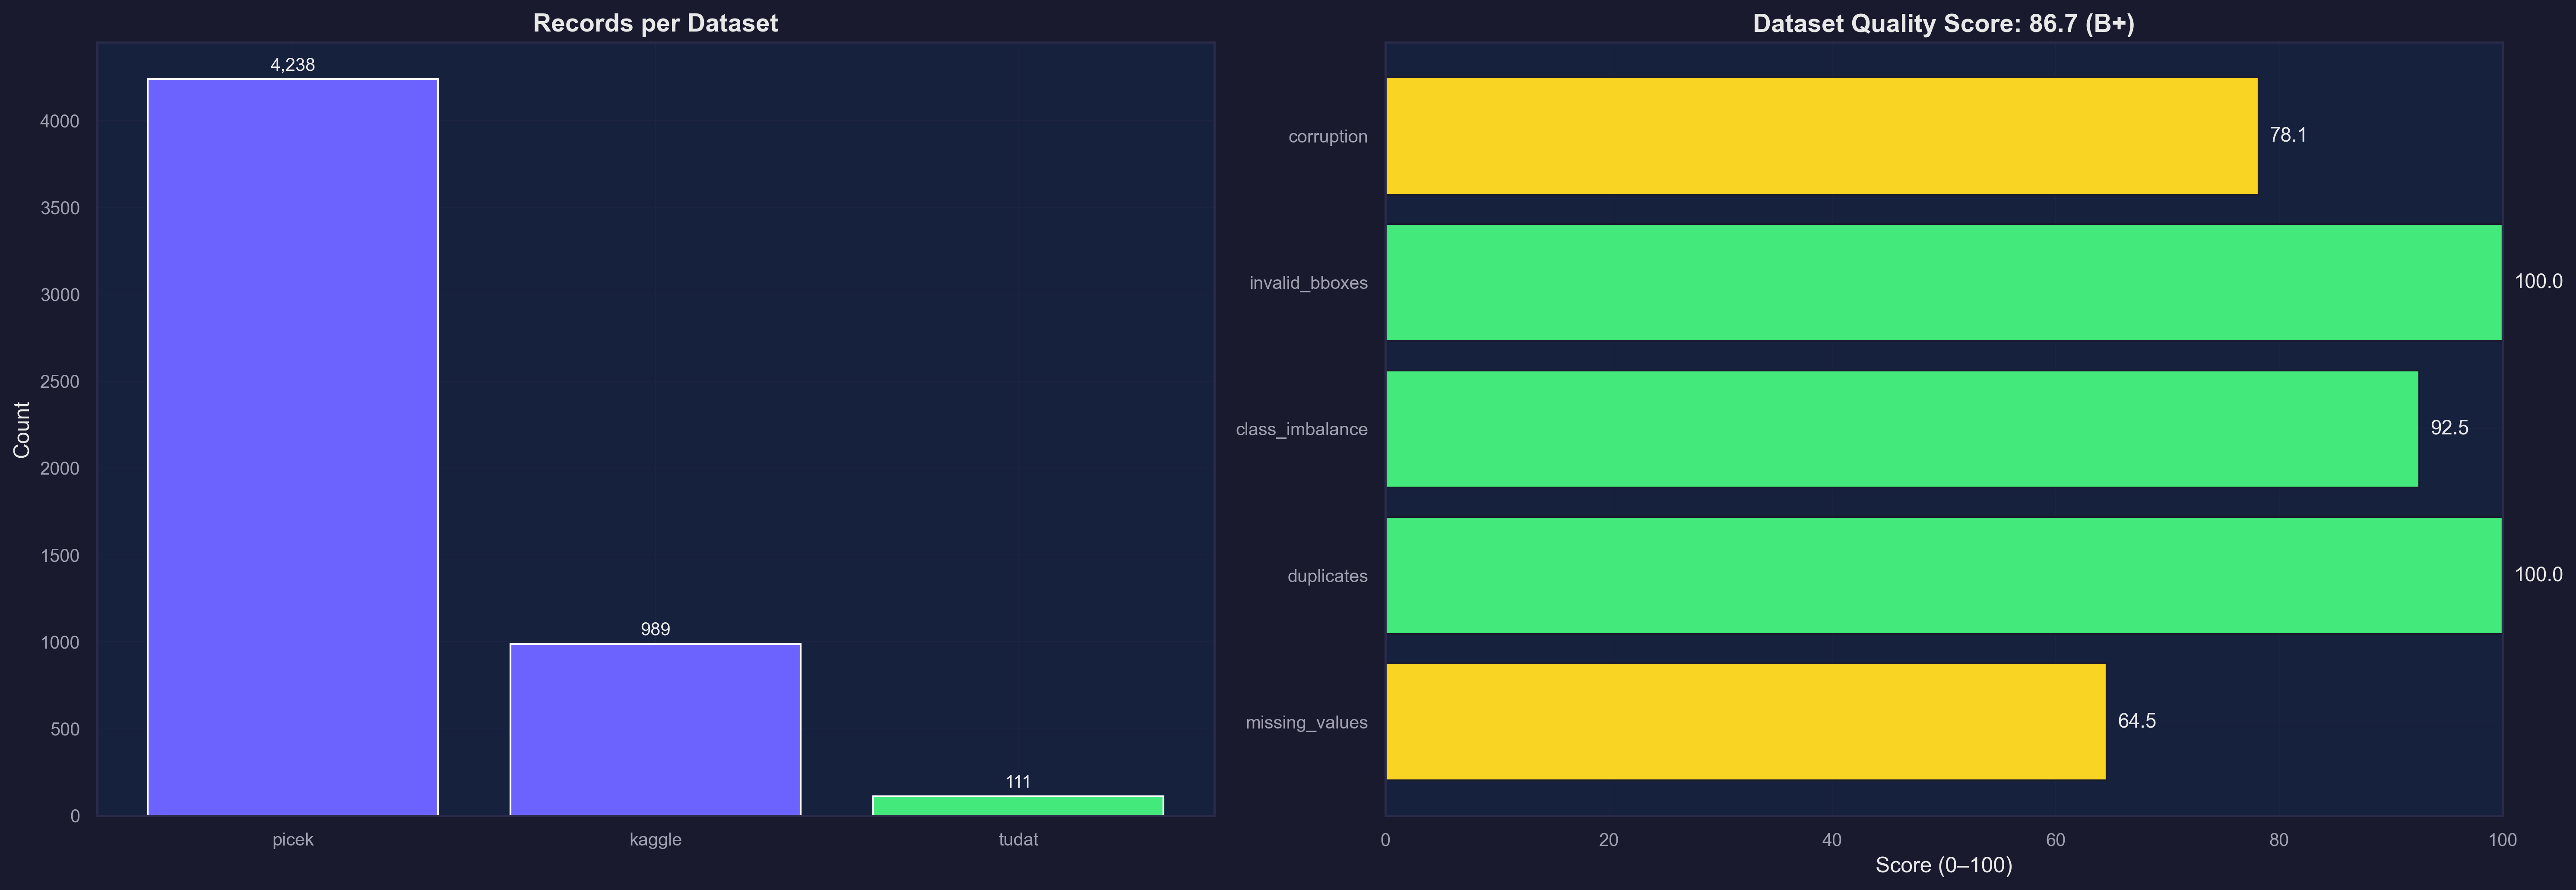

In [6]:
# Per-dataset distribution
fig, axes = plot_engine.create_figure(nrows=1, ncols=2, figsize=(20, 7))

# Left: records per dataset
ds_counts = pd.DataFrame(overview_results["per_dataset_counts"])
colors = [DATASET_COLOURS.get(n, "#6C63FF") for n in ds_counts["dataset"]]
axes[0].bar(ds_counts["dataset"], ds_counts["count"], color=colors)
axes[0].set_title("Records per Dataset", fontweight="bold")
axes[0].set_ylabel("Count")
for i, row in ds_counts.iterrows():
    axes[0].text(i, row["count"] + 50, f"{row['count']:,}", ha="center", fontsize=10)

# Right: quality score breakdown
plot_engine.plot_quality_score_breakdown(
    {k: v["raw"] for k, v in quality["components"].items()},
    quality["overall"],
    quality["grade"],
    ax=axes[1],
)

plt.tight_layout()
output.save_figure(fig, "summary_overview")
wb.log_figure(fig, "summary_overview")
plt.show()

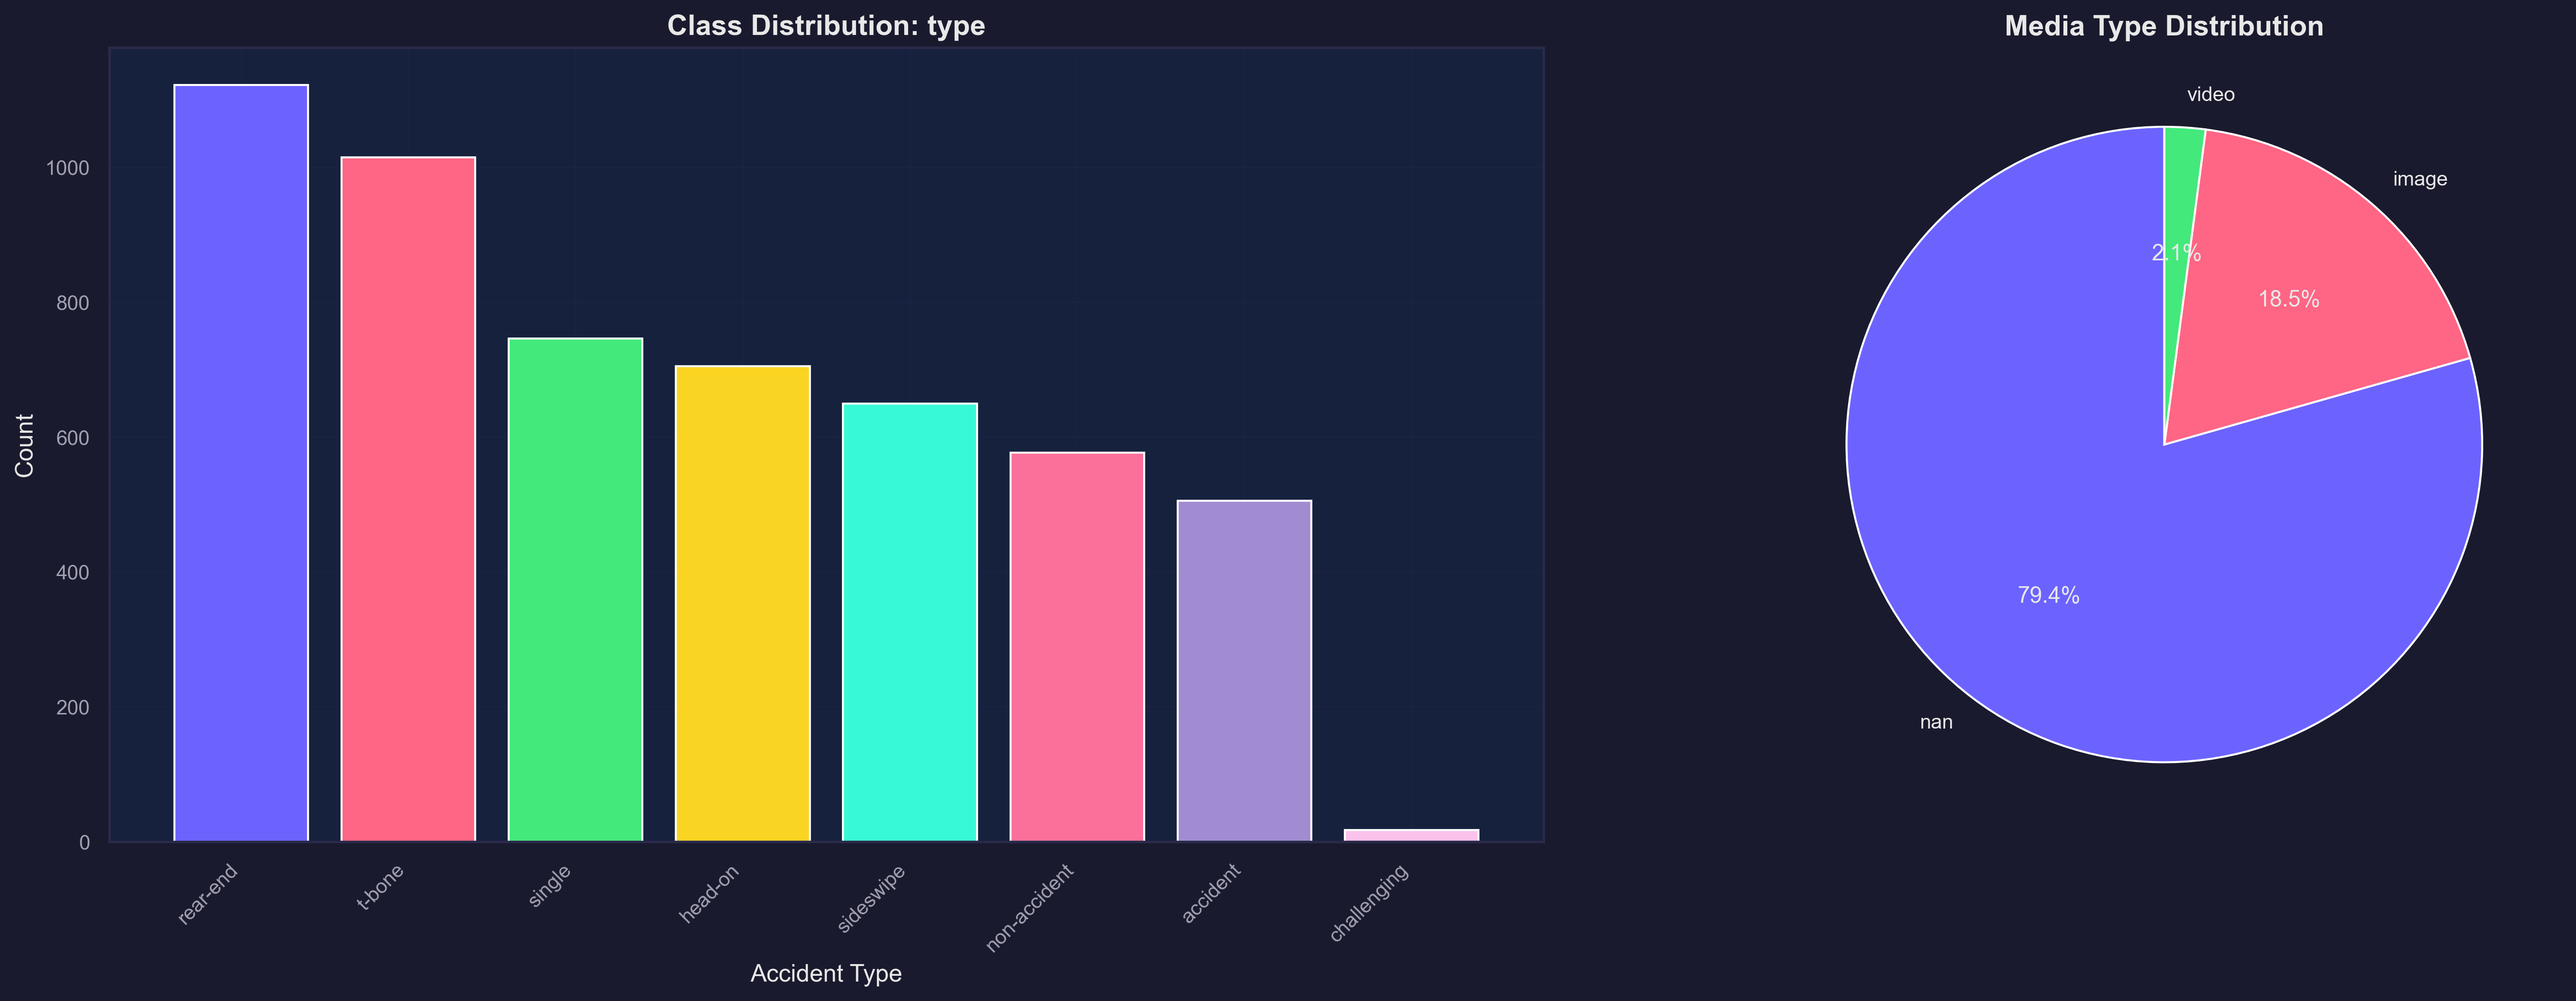

In [7]:
# Class distribution + media type side by side
fig, axes = plot_engine.create_figure(nrows=1, ncols=2, figsize=(20, 7))

# Left: primary label distribution
if primary.get("available") and config.primary_label in df.columns:
    plot_engine.plot_bar_chart(
        df[config.primary_label].dropna(),
        title=f"Class Distribution: {config.primary_label}",
        xlabel="Accident Type",
        ax=axes[0],
    )

# Right: media type
media = overview_results.get("media_types", {})
if media.get("distribution"):
    mt_data = media["distribution"]
    if isinstance(mt_data, dict):
        mt_series = pd.Series(mt_data)
        axes[1].pie(
            mt_series.values, labels=mt_series.index,
            colors=CATEGORICAL_COLOURS[:len(mt_series)],
            autopct="%1.1f%%", startangle=90,
            textprops={"color": PALETTE["text"]},
        )
        axes[1].set_title("Media Type Distribution", fontweight="bold")

plt.tight_layout()
output.save_figure(fig, "class_and_media")
wb.log_figure(fig, "class_and_media")
plt.show()

## Report & Export

In [8]:
rg = ReportGenerator(
    NOTEBOOK_NAME,
    eda_version=config.eda_version,
    dataset_version=loader.dataset_version,
    metadata_hash=metadata_hash,
    git_commit=git_commit,
    seed=config.seed,
)

# At a glance
rg.add_heading("Dataset at a Glance")
rg.add_key_value_list({
    "Total Records": f"{dims['rows']:,}",
    "Total Columns": dims["columns"],
    "Datasets": len(overview_results["per_dataset_counts"]),
    "Unique Classes": primary.get("unique_classes", "N/A"),
    "Quality Score": f"{quality['overall']:.1f} ({quality['grade']})",
    "Memory Footprint": f"{overview_results['memory_footprint']['total_mb']:.1f} MB",
})

# Per-dataset table
rg.add_heading("Per-Dataset Comparison")
rg.add_table(ds_counts, key="per_dataset_comparison")

# Findings
rg.add_heading("Critical Findings")
if findings:
    for f in findings:
        rg.add_key_value_list({"Finding": f})
else:
    rg.add_key_value_list({"Status": "No critical findings"})

# Quality Score
rg.add_heading("Composite Dataset Quality Score")
score_rows = [
    {"component": k, "score": v["score"], "weight": v["weight"]}
    for k, v in quality["components"].items()
]
score_df = pd.DataFrame(score_rows)
rg.add_table(score_df, key="quality_score")

# Class balance summary
rg.add_heading("Class Balance Summary")
if primary.get("available"):
    rg.add_key_value_list({
        "Unique Classes": primary["unique_classes"],
        "Imbalance Ratio": f"{primary['imbalance_ratio']:.2f}",
        "Entropy": f"{primary['entropy']:.4f} bits",
    })

# Build summary statistics CSV
summary_rows = [
    {"metric": "total_records", "value": dims["rows"]},
    {"metric": "total_columns", "value": dims["columns"]},
    {"metric": "datasets", "value": len(overview_results["per_dataset_counts"])},
    {"metric": "quality_score", "value": quality["overall"]},
    {"metric": "quality_grade", "value": quality["grade"]},
    {"metric": "unique_classes", "value": primary.get("unique_classes", 0)},
    {"metric": "imbalance_ratio", "value": primary.get("imbalance_ratio", 0)},
    {"metric": "exact_duplicates", "value": dups["exact_row_duplicates"]},
    {"metric": "bbox_invalid_count", "value": bbox_results.get("validation", {}).get("total_invalid", 0)},
    {"metric": "memory_mb", "value": overview_results["memory_footprint"]["total_mb"]},
]
summary_df = pd.DataFrame(summary_rows)
output.save_csv(summary_df, "eda_summary_statistics")

rg.add_stats({
    "total_records": dims["rows"],
    "total_columns": dims["columns"],
    "datasets": len(overview_results["per_dataset_counts"]),
    "quality_overall": quality["overall"],
    "quality_grade": quality["grade"],
    "unique_classes": primary.get("unique_classes", 0),
    "imbalance_ratio": primary.get("imbalance_ratio", 0),
    "findings_count": len(findings),
    "findings": findings,
})

output.save_report(rg.build_markdown(), "final_eda_summary_report")
output.save_summary_json(rg.build_summary_json(), "summary")

# W&B logging
wb.log_stats({
    "summary/total_records": dims["rows"],
    "summary/quality_score": quality["overall"],
    "summary/quality_grade": quality["grade"],
    "summary/unique_classes": primary.get("unique_classes", 0),
    "summary/imbalance_ratio": primary.get("imbalance_ratio", 0),
    "summary/findings_count": len(findings),
})
wb.log_table(summary_df, "eda_summary_statistics")
wb.log_table(score_df, "quality_score_breakdown")

print("Reports and exports saved.")

W&B log_table failed for 'eda_summary_statistics': Data row contained incompatible types:
{'metric': 'quality_grade', 'value': 'B+'} of type {'metric': String, 'value': String} is not assignable to {'metric': None or String, 'value': None or Number}
Key 'value':
	String not assignable to None or Number
		String not assignable to None
	and
		String not assignable to Number


Reports and exports saved.


## Teardown

In [9]:
snap_end = monitor.snapshot("end")
duration = time.time() - START_TIME

wb.log_system_info(snap_end)
wb.log_stats({"execution/duration_seconds": round(duration, 2)})
wb.log_notebook_outputs(
    output.figures_dir, output.reports_dir, output.exports_dir,
    metadata={"notebook": NOTEBOOK_NAME, "duration": round(duration, 2)},
)

output.finalize(
    wandb_run_id=wb.run_id, wandb_run_url=wb.run_url,
    git_commit=git_commit, metadata_hash=metadata_hash,
    rows_analyzed=df.shape[0], duration_seconds=duration,
)
logger.log_execution_summary(
    duration_seconds=duration, files_exported=output.all_exported_files,
    wandb_run_id=wb.run_id, wandb_run_url=wb.run_url,
)
wb.finish()

print(f"\n✅ Final EDA Summary complete in {duration:.1f}s")
print(f"   Exported {len(output.all_exported_files)} files")
print(f"   Quality Score: {quality['overall']:.1f} ({quality['grade']})")

wandb: Adding directory to artifact (E:\Rads\eda\figures\2026-08-01_16-45)... 

Done. 0.0s


wandb: Adding directory to artifact (E:\Rads\eda\reports\2026-08-01_16-45)... 

Done. 0.0s


wandb: Adding directory to artifact (E:\Rads\eda\exports\2026-08-01_16-45)... 

...

wandb: uploading data


wandb: 
wandb: Run history:
wandb: execution/duration_seconds ▁
wandb:     summary/findings_count ▁
wandb:    summary/imbalance_ratio ▁
wandb:      summary/quality_score ▁
wandb:      summary/total_records ▁
wandb:     summary/unique_classes ▁
wandb:           system/cpu/cores ▁▁
wandb:         system/cpu/percent █▁
wandb:        system/disk/percent ▁▁
wandb:        system/disk/used_gb ▁▁
wandb:                         +3 ...
wandb: 
wandb: Run summary:
wandb: execution/duration_seconds 18.74
wandb:     summary/findings_count 2
wandb:    summary/imbalance_ratio 66
wandb:      summary/quality_grade B+
wandb:      summary/quality_score 86.7
wandb:      summary/total_records 5338
wandb:     summary/unique_classes 8
wandb:           system/cpu/cores 4
wandb:         system/cpu/percent 32.8
wandb:        system/disk/percent 68.7
wandb:                         +4 ...
wandb: 


wandb:  View run eda-06_final_eda_summary at: https://wandb.ai/saksham4data-vinkura/RADS/runs/us8n0ygz
wandb:  View project at: https://wandb.ai/saksham4data-vinkura/RADS
wandb: Synced 5 W&B file(s), 3 media file(s), 10 artifact file(s) and 0 other file(s)


wandb: Find logs at: .\wandb\run-20260801_221517-us8n0ygz\logs



✅ Final EDA Summary complete in 18.7s
   Exported 7 files
   Quality Score: 86.7 (B+)
